In [1]:
import numpy as np
np.bool = np.bool_ 
import pandas as pd
import os
from tqdm import tqdm

import mxnet as mx
from mxnet import gluon
from mxnet import autograd
from mxnet import image

import sys
sys.path.append('resuneta/src')
sys.path.append('decode/FracTAL_ResUNet/models/semanticsegmentation')
sys.path.append('decode/FracTAL_ResUNet/nn/loss')
sys.path.append('autogeobound/MXNet-ResUNeta/')

from bound_dist import get_distance, get_boundary
from FracTAL_ResUNet import FracTAL_ResUNet_cmtsk
#from ftnmt_loss import ftnmt_loss
from datasets import *

from sklearn.metrics import matthews_corrcoef

import random

import rasterio
from rasterio.enums import ColorInterp
from rasterio.features import shapes
from scipy import ndimage

import matplotlib.pyplot as plt
%matplotlib inline

import higra as hg
import torch
import pickle

import itertools

import imageio.v3 as imageio
from skimage.color import label2rgb
import cv2
from skimage.segmentation import mark_boundaries
from skimage.segmentation import find_boundaries

from shapely.geometry import shape
import shapely

In [2]:
data = pd.read_csv('calibration_data/calibration_points_with_sampled_coords.csv')

In [3]:
image_filenames = data["image_filename"]

In [4]:
n_filters = 32
depth = 6
n_classes = 1
#ctx = mx.gpu(2)
ctx = mx.cpu(0)
model = FracTAL_ResUNet_cmtsk(nfilters_init=n_filters, depth=depth, NClasses=n_classes)
model.load_parameters('experiments/8m-resolution/US/fractal-resunet_NAIP_nfilter-32_depth-6_bs-80_lr-0.001/model-20epoch.params', ctx=ctx)

# https://stackoverflow.com/questions/66595055/fastest-way-of-computing-binary-mask-iou-with-numpy
def iou(mask1, mask2):
    intersection = (mask1 * mask2).sum()
    if intersection == 0:
        return 0.0
    union = torch.logical_or(mask1, mask2).to(torch.int).sum()
    return intersection / union

'''
def erode_fields(segmentation):
    unique_labels = np.unique(segmentation)
    extent = np.zeros_like(segmentation)
    field_original_with_border = np.ones((segmentation.shape[0]+2, segmentation.shape[1]+2))
    for label in unique_labels:
        field_original = (segmentation==label).astype(int)
        field_original_with_border[1:-1, 1:-1] = field_original
        field_extent = ndimage.binary_erosion(field_original_with_border).astype(int)[1:-1, 1:-1]
        extent += field_extent
    return extent
'''

def predict_boundaries_512(image):
    bound = np.zeros((512, 512))
    count = np.zeros((512, 512))
    topleft_indices = list(itertools.product([0, 128, 256], [0, 128, 256]))
    for topleft_index in topleft_indices:
        x1, x2, y1, y2 = topleft_index[0], topleft_index[0]+256, topleft_index[1], topleft_index[1]+256
        image_crop = mx.nd.array(image[:, :, x1:x2, y1:y2])
        _, bound_crop, _ = model(image_crop.as_in_context(ctx))
        bound[x1:x2, y1:y2] += bound_crop[0][0].asnumpy()
        count[x1:x2, y1:y2] += np.ones((256, 256))
    bound /= count
    return bound

def predict_segmentations_1536(image, Ts):
    pred_segmentations = np.zeros((len(Ts), 1536, 1536))
    topleft_indices = list(itertools.product([0, 512, 1024], [0, 512, 1024]))
    for topleft_index in topleft_indices:
        x1, x2, y1, y2 = topleft_index[0], topleft_index[0]+512, topleft_index[1], topleft_index[1]+512
        bound = predict_boundaries_512(image[:, :, x1:x2, y1:y2])
        graph = hg.get_8_adjacency_graph((512, 512))
        edge_weights = hg.weight_graph(graph,bound,hg.WeightFunction.mean)
        tree, altitudes = hg.watershed_hierarchy_by_dynamics(graph, edge_weights)
        for i, T in enumerate(Ts):
            pred_segmentation = hg.labelisation_horizontal_cut_from_threshold(tree,altitudes,threshold=T).astype(float) + 1 # ensure no fields are 0
            #contours, hierarchy = cv2.findContours(cv2.convertScaleAbs(pred_segmentation), cv2.RETR_TREE, cv2.CHAIN_APPROX_SIMPLE)
            #binary_field_extent = cv2.drawContours(pred_segmentation.astype(np.uint8), contours, -1, 0, 1) > 0
            binary_field_extent = find_boundaries(pred_segmentation)==0
            pred_segmentations[i, x1:x2, y1:y2] = binary_field_extent
    for i, T in enumerate(Ts):
        ndimage.label(pred_segmentations[i], output=pred_segmentations[i])
        ndimage.grey_dilation(pred_segmentations[i], size=(3, 3), output=pred_segmentations[i])
    return pred_segmentations

depth:= 0, nfilters: 32, nheads::8, widths::1
depth:= 1, nfilters: 64, nheads::16, widths::1
depth:= 2, nfilters: 128, nheads::32, widths::1
depth:= 3, nfilters: 256, nheads::64, widths::1
depth:= 4, nfilters: 512, nheads::128, widths::1
depth:= 5, nfilters: 1024, nheads::256, widths::1
depth:= 6, nfilters: 512, nheads::256, widths::1
depth:= 7, nfilters: 256, nheads::128, widths::1
depth:= 8, nfilters: 128, nheads::64, widths::1
depth:= 9, nfilters: 64, nheads::32, widths::1
depth:= 10, nfilters: 32, nheads::16, widths::1


  0%|          | 0/1 [00:00<?, ?it/s]

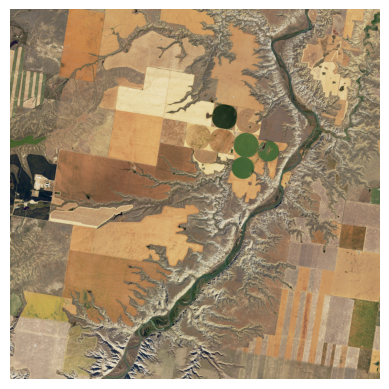

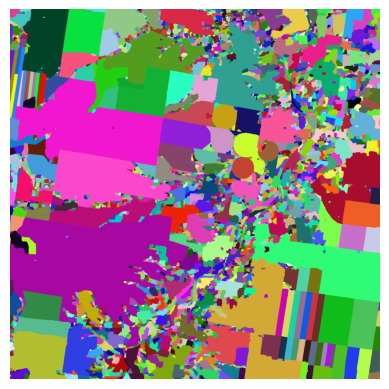

100%|██████████| 1/1 [00:54<00:00, 54.69s/it]


In [5]:
Ts = [0.1]
for image_filename in tqdm([image_filenames[0]]):
    image = imageio.imread(image_filename)
    plt.imshow(image[:, :, :3])
    plt.axis('off')
    plt.show()

    image = np.moveaxis(image, -1, 0)[np.newaxis, :]
    pred_segmentations = predict_segmentations_1536(image, Ts)

    for i in range(len(Ts)):
        unique_labels = np.unique(pred_segmentations[i])
        colors = [(np.random.rand(), np.random.rand(), np.random.rand()) for _ in unique_labels]
        pred_segmentation = label2rgb(pred_segmentations[i], bg_label=0, bg_color=(0, 0, 0), colors=colors)
        plt.imshow(pred_segmentation)
        plt.axis('off')
        plt.show()

In [6]:
# https://stackoverflow.com/questions/78536698/using-python-can-one-convert-a-tiff-file-to-a-gpkg-file-such-that-all-raster
#metadata = imageio.immeta(image_filename)
#transform = metadata['ModelTransformation']
project = pyproj.Transformer.from_proj(
    pyproj.Proj(init='epsg:5070'),
    pyproj.Proj(init='epsg:4326')) 

src = rasterio.open(image_filename)
for i in tqdm(range(len(Ts))):
    pred_segmentation = pred_segmentations[i]
    #unique_labels, counts = np.unique(pred_segmentation, return_counts=True)
    #remove_mask = np.isin(pred_segmentation, unique_labels[counts < 60]) # remove small fields 
    #pred_segmentation[remove_mask] = 0
    results = [shape(s) for (s, v) in shapes(source=pred_segmentation, mask=pred_segmentation>0, transform=src.transform)]

100%|██████████| 1/1 [00:00<00:00,  4.62it/s]


In [7]:
len(results)

3374

In [8]:
df = pd.DataFrame({'geometry':results})

In [9]:
df.to_csv('testing/example_predicted_fields.csv', index=False)

In [19]:
print(df.iloc[0]['geometry'])

POLYGON ((-1095768 2887680, -1095768 2887664, -1095720 2887664, -1095720 2887656, -1095624 2887656, -1095624 2887680, -1095768 2887680))


# Test how long calibration takes for one image

In [10]:
T_values = np.concatenate([[0], np.arange(0.001, 0.01, 0.001), np.arange(.01, 1.01, .01)])
for image_filename in tqdm(image_filenames[:5]):
    image = imageio.imread(image_filename)
    image = np.moveaxis(image, -1, 0)[np.newaxis, :]
    topleft_indices = list(itertools.product([0, 512, 1024], [0, 512, 1024]))
    trees_list = []
    altitudes_list = []
    bbox_coords_list = []
    for topleft_index in topleft_indices:
        x1, x2, y1, y2 = topleft_index[0], topleft_index[0]+512, topleft_index[1], topleft_index[1]+512
        bound = predict_boundaries_512(image[:, :, x1:x2, y1:y2])
        '''
        graph = hg.get_8_adjacency_graph((512, 512))
        edge_weights = hg.weight_graph(graph,bound,hg.WeightFunction.mean)
        tree, altitudes = hg.watershed_hierarchy_by_dynamics(graph, edge_weights)
        trees_list.append(tree)
        altitudes_list.append(altitudes)
        bbox_coords_list.append((x1, x2, y1, y2))
    
    for T in T_values:
        out = np.zeros((1536, 1536))
        for j in range(len(topleft_indices)):
            x1, x2, y1, y2 = bbox_coords_list[j]
            tree = trees_list[j]
            altitudes = altitudes_list[j]
            pred_segmentation = hg.labelisation_horizontal_cut_from_threshold(tree,altitudes,threshold=T).astype(float) + 1 # ensure no fields are 0
            binary_field_extent = find_boundaries(pred_segmentation)==0
            out[x1:x2, y1:y2] = binary_field_extent
        ndimage.label(out, output=out)
        ndimage.grey_dilation(out, size=(3, 3), output=out)
    '''

100%|██████████| 5/5 [00:36<00:00,  7.25s/it]
